In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Считываю данные

In [2]:
df = pd.read_csv('bmw.csv')
X = df.drop(columns='price')
y = df.price

In [3]:
X.head(5)

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,Automatic,39554,Diesel,160,50.4,3.0


In [4]:
#1 Проверяю данные
#1.1 Общая информация о данных
print(df.shape)       # Сколько строк и столбцов
print(df.info())      # Типы данных и наличие пропусков

(10781, 9)
<class 'pandas.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10781 non-null  str    
 1   year          10781 non-null  int64  
 2   price         10781 non-null  int64  
 3   transmission  10781 non-null  str    
 4   mileage       10781 non-null  int64  
 5   fuelType      10781 non-null  str    
 6   tax           10781 non-null  int64  
 7   mpg           10781 non-null  float64
 8   engineSize    10781 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 758.2 KB
None


In [5]:
# 1.1. Пропуски (NaN)
print("\n--- Пропуски в столбцах ---")
print(df.isnull().sum())


--- Пропуски в столбцах ---
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64


In [6]:
# 1.2. Проверка на дубликаты
duplicates = df.duplicated().sum()
print(f"\n--- Дубликаты: {duplicates} ---")


--- Дубликаты: 117 ---


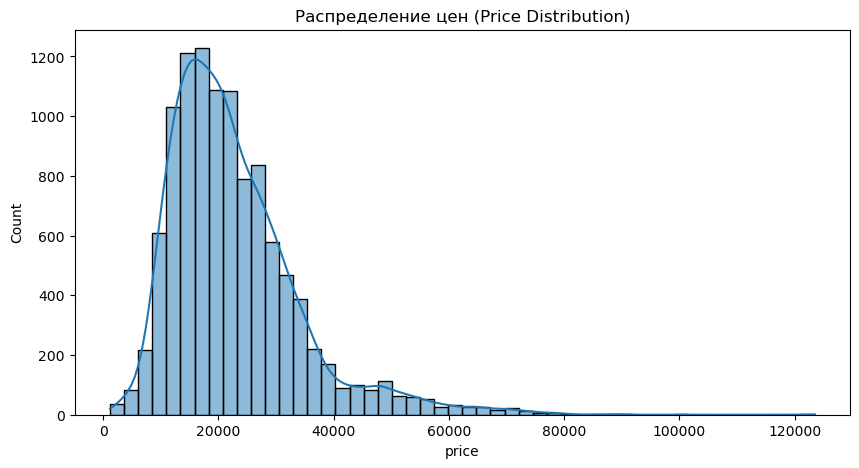

In [7]:
# 1.3. Распределение целевой переменной (Цены)
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Распределение цен (Price Distribution)')
plt.show()

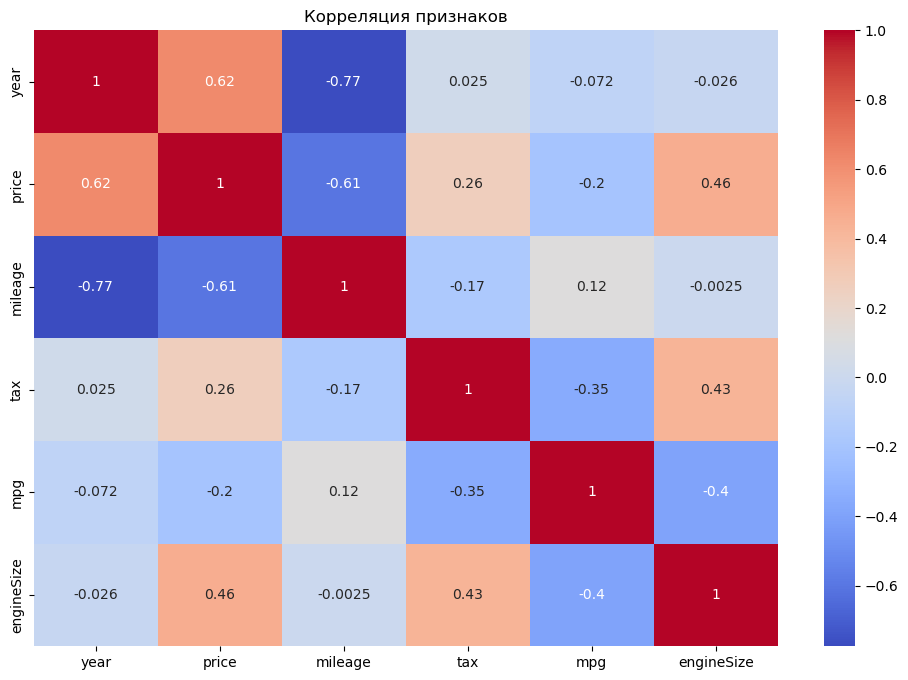

In [8]:
# Смотрим, какие числовые признаки сильнее всего связаны с ценой
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Корреляция признаков')
plt.show()

Сильная корреляция:   1. year и mileage (-0.77) 2.year и price (0.62) 3. price и mileage (-0.61)
Умеренная корреляция: 1. price и enginSize (0.46) 2. tax и engineSize (0.43) 3.mpg и enginexize (-0.4)
Слабая корреляция:    1. tax, mpg (-0.35)   2.year,tax (0.025) 3.mileage, engineSize (-0.0025)

In [9]:
#Изучаем категориальные признаки
cat_cols = ['fuelType', 'transmission', 'model']  # замените на ваши названия

for col in cat_cols:
    print(f"\n=== {col} ===")
    print(f"Уникальных значений: {df[col].nunique()}")
    print(f"Пропуски: {df[col].isnull().sum()}")
    print("\nТоп-10 значений:")
    print(df[col].value_counts().head(10))
    print("\nРаспределение (%):")
    print(df[col].value_counts(normalize=True).head(10) * 100)


=== fuelType ===
Уникальных значений: 5
Пропуски: 0

Топ-10 значений:
fuelType
Diesel      7027
Petrol      3417
Hybrid       298
Other         36
Electric       3
Name: count, dtype: int64

Распределение (%):
fuelType
Diesel      65.179482
Petrol      31.694648
Hybrid       2.764122
Other        0.333921
Electric     0.027827
Name: proportion, dtype: float64

=== transmission ===
Уникальных значений: 3
Пропуски: 0

Топ-10 значений:
transmission
Semi-Auto    4666
Automatic    3588
Manual       2527
Name: count, dtype: int64

Распределение (%):
transmission
Semi-Auto    43.279844
Automatic    33.280772
Manual       23.439384
Name: proportion, dtype: float64

=== model ===
Уникальных значений: 24
Пропуски: 0

Топ-10 значений:
model
3 Series    2443
1 Series    1969
2 Series    1229
5 Series    1056
4 Series     995
X1           804
X3           551
X5           468
X2           288
X4           179
Name: count, dtype: int64

Распределение (%):
model
3 Series    22.660236
1 Series    18.

fuelType     - 5 уникальных. Распределение 65%, 32%, 2%
transmission - 3 уникальных. Распределение 43%, 33%, 23%  - сбалансировано
model        - 24 уникальных. Распределение 22%, 18%, 23%  + хвост из редких

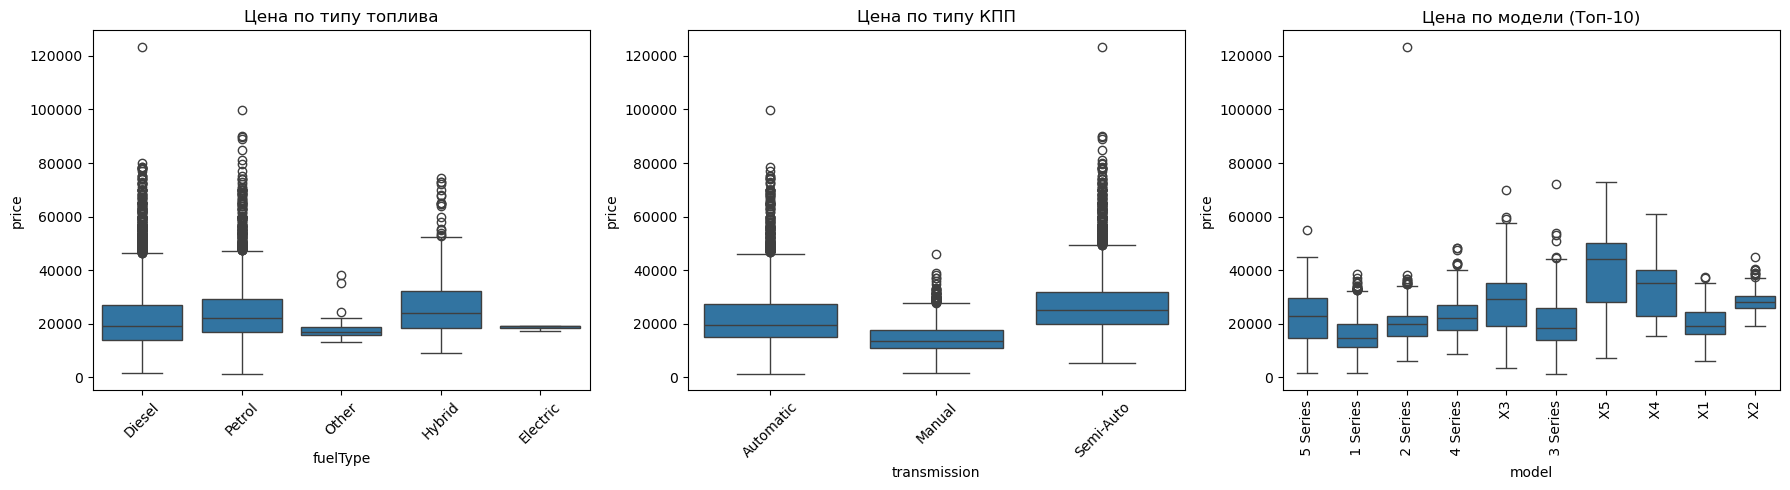

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# fuelType vs price
sns.boxplot(data=df, x='fuelType', y='price', ax=axes[0])
axes[0].set_title('Цена по типу топлива')
axes[0].tick_params(axis='x', rotation=45)

# transmission vs price
sns.boxplot(data=df, x='transmission', y='price', ax=axes[1])
axes[1].set_title('Цена по типу КПП')
axes[1].tick_params(axis='x', rotation=45)

# model vs price (топ-10)
top_models = df['model'].value_counts().nlargest(10).index
df_top = df[df['model'].isin(top_models)]
sns.boxplot(data=df_top, x='model', y='price', ax=axes[2])
axes[2].set_title('Цена по модели (Топ-10)')
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

Вывод:
1. Тип топлива (fuelType) влияет на цену не критично. У Other и Electric мало данных, медиана правктически одинакова и их можно объединить
2. transmission сильно влияет на на цену (есть дорогие выбросы)
3. model сильно влияет на цену, четкая иерархия. Разброс цен внутри модели большой.

transmission, model - фундаментальные признаки

Вывод из анализа:
1. Пропусков нет
2. Дубликаты есть!!! Нужно убрать
3. Аномалий в распределении цены нет
4. Важные столбцы для предсказания цены: year, mileage, engineSize.  engineSize связан с tax и mpg.
   Но year и mileage: -0.77 (пограничное значение)-мультиколлинеарность
5. model, transmission - фундаментальные (категориальные) признаки. Их нужно кодировать
   fuletype - лучше сгруппировать редкие признаки

In [11]:
# fuelType: объединяем Electric и Other - группируем редкие признаки
df['fuelType'] = df['fuelType'].replace(
    ['Electric', 'Other'], 'Other'
)

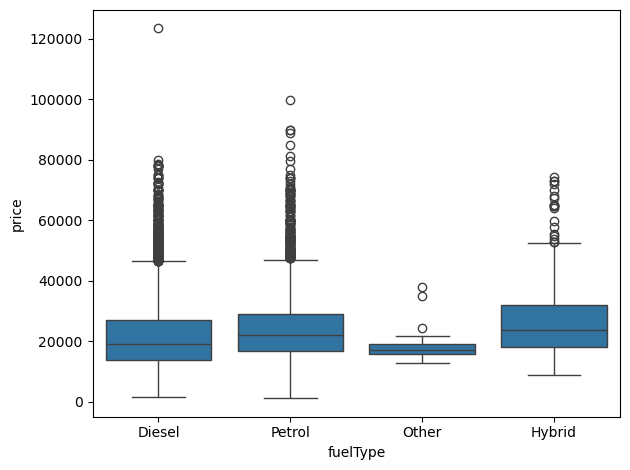

In [12]:
# fuelType vs price
sns.boxplot(data=df, x='fuelType', y='price')
plt.tight_layout()
plt.show()

In [13]:
#Убираем дубликаты
print(f"До очистки: {df.shape}")

# Шаг 1: Посчитать дубликаты
duplicates_count = df.duplicated().sum()
print(f"Найдено дубликатов: {duplicates_count}")

# Шаг 2: Если есть — показать пример
if duplicates_count > 0:
    print("\nПример дубликатов:")
    print(df[df.duplicated(keep=False)].head())

# Шаг 3: Удалить
df = df.drop_duplicates()

# Шаг 4: Проверить результат
print(f"\nПосле очистки: {df.shape}")
print(f"Удалено строк: {duplicates_count}")

До очистки: (10781, 9)
Найдено дубликатов: 117

Пример дубликатов:
         model  year  price transmission  mileage fuelType  tax   mpg  \
173         X4  2019  33998    Semi-Auto     7272   Diesel  150  42.8   
174         X4  2019  33998    Semi-Auto     7272   Diesel  150  42.8   
379         X1  2018  16995    Semi-Auto    17276   Petrol  150  46.3   
393         X1  2018  16995    Semi-Auto    17276   Petrol  150  46.3   
643   1 Series  2019  21898       Manual     4100   Petrol  150  41.5   

     engineSize  
173         2.0  
174         2.0  
379         1.5  
393         1.5  
643         1.5  

После очистки: (10664, 9)
Удалено строк: 117


Разделение на train и test

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8,  random_state = 42)

In [15]:
import category_encoders as ce

# Вместо OneHotEncoder использую TargetEncoder
# Заменяем категорию на среднее значение целевой переменной. Помогает избежать создания огромного числа столбцов
#encoder = ce.one_hot.OneHotEncoder(cols=['model', 'transmission', 'fuelType'])
    
encoder = ce.TargetEncoder(cols=['model', 'transmission', 'fuelType'])
X_train = encoder.fit_transform(X_train, y_train)  
X_test = encoder.transform(X_test)

print(f"После Target Encoding: {X_train.shape[1]} столбцов")

После Target Encoding: 8 столбцов


Данные подготовлены для обучения

In [16]:
X_train.head(10)

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
3652,22649.220118,2019,27378.582860,9165,24287.777411,145,50.4,2.0
7007,39407.904509,2019,22351.619048,6650,21709.621290,145,37.7,3.0
9045,22649.220118,2016,22351.619048,64231,21709.621290,145,53.3,3.0
3910,34184.700718,2019,22351.619048,2799,27485.882844,135,141.2,1.5
3635,39407.904509,2013,22351.619048,63583,21709.621290,200,45.6,3.0
1880,22649.220118,2014,27378.582860,35822,21709.621290,165,51.4,3.0
8661,19776.511236,2016,22351.619048,52000,21709.621290,30,64.2,2.0
2627,15757.759875,2019,14609.297852,10,24287.777411,145,44.1,1.5
9334,19505.120361,2016,14609.297852,18840,24287.777411,125,52.3,1.5
6536,39407.904509,2017,22351.619048,11197,21709.621290,200,47.1,3.0


In [53]:
#Линейная регрессия SGDRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SGDRegressor(random_state=42, max_iter=1000, tol=1e-3))
])

params = {    
    'model__alpha': [0.0001, 0.001, 0.01],
    'model__penalty':['l2', 'l1', 'elasticnet'],
    'model__learning_rate': ['constant', 'optimal']    
}
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

#random_state=42 зафиксирован в двух местах:
#В SGDRegressor — чтобы инициализация весов и порядок батчей были одинаковыми
#В KFold — чтобы разбиение данных на фолды было одинаковым

modelLR = GridSearchCV(pipe, params,  cv=kfold, n_jobs=-1, scoring='r2')

In [54]:
modelLR.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.0001, 0.001, ...], 'model__learning_rate': ['constant', 'optimal'], 'model__penalty': ['l2', 'l1', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation ti

In [55]:
modelLR.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l1'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.01
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 correspond

In [56]:
y_predLR = modelLR.predict(X_test)

In [57]:
#Случайный лес
from sklearn.ensemble import RandomForestRegressor 
pipe_RF = Pipeline([
    ('model', RandomForestRegressor(max_depth=15, random_state=42))
])
params_RF = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [10, 15, None]
}

modelRF = GridSearchCV(pipe_RF, params_RF, cv=kfold, n_jobs=-1, scoring='r2')


In [58]:
modelRF.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [10, 15, ...], 'model__n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;-

In [59]:
y_predRF = modelRF.predict(X_test)

In [60]:
# Метрики качества

from sklearn.metrics import r2_score  
print(f"LR {r2_score(y_test, y_predLR)}")
print(f"RF {r2_score(y_test, y_predRF)}")


LR 0.8245769997086729
RF 0.9468443535633455


In [61]:
# Кроссвалидация
from sklearn.model_selection import cross_val_score

scores_LR=cross_val_score(modelLR.best_estimator_, X_train, y_train, cv=kfold)

In [62]:
scores_LR

array([0.85620883, 0.79579792, 0.84474746, 0.83302889, 0.82938292])

In [63]:
 print(modelLR.best_score_)
 print(modelRF.best_score_)


0.8318332045800659
0.9462385655647292
